# Notebook 03 — Sélection de Caractéristiques



---
### Les 3 familles 
```
1. Filter Methods    → propriétés statistiques, indépendantes du modèle
   ├─ Variance Threshold
   ├─ Corrélation de Pearson
   ├─ Corrélation de Spearman
   ├─ Test du Chi²
   └─ ANOVA (F-test)

2. Wrapper Methods   → utilisent un modèle pour évaluer les sous-ensembles
   ├─ Forward Selection
   ├─ Backward Elimination
   └─ RFE (avec LR, SVM, RF)

3. Embedded Methods  → sélection intégrée dans l'apprentissage
   ├─ Lasso (ℓ1)
   ├─ Elastic Net (ℓ1 + ℓ2)
   ├─ Random Forest importance
   └─ Gradient Boosting importance
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection  import (VarianceThreshold, chi2, f_classif,
                                         RFE, SequentialFeatureSelector)
from sklearn.linear_model       import LogisticRegression, LassoCV, ElasticNetCV
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing      import MinMaxScaler
from scipy                      import stats
from IPython.display            import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

PROC = '../data/processed/'
REP  = '../reports/'
SEED = 42

X_train = pd.read_csv(f'{PROC}X_train.csv').fillna(0)
X_test  = pd.read_csv(f'{PROC}X_test.csv').fillna(0)
y_train = pd.read_csv(f'{PROC}y_train.csv').squeeze()
y_test  = pd.read_csv(f'{PROC}y_test.csv').squeeze()

features = X_train.columns.tolist()
print(f'Features : {len(features)}')
print(features)

Features : 27
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlySpend', 'tenure_group', 'num_services', 'is_new_customer']


---
# FAMILLE 1 — Filter Methods
> *"Méthodes basées uniquement sur les propriétés statistiques des données. Indépendantes du modèle."*  
> *Avantages : très rapides, simples à implémenter. Inconvénients : ignorent les interactions entre variables.*  


## 1.1 Variance Threshold
Supprime les features dont la variance est quasi-nulle (apportent peu d'information).

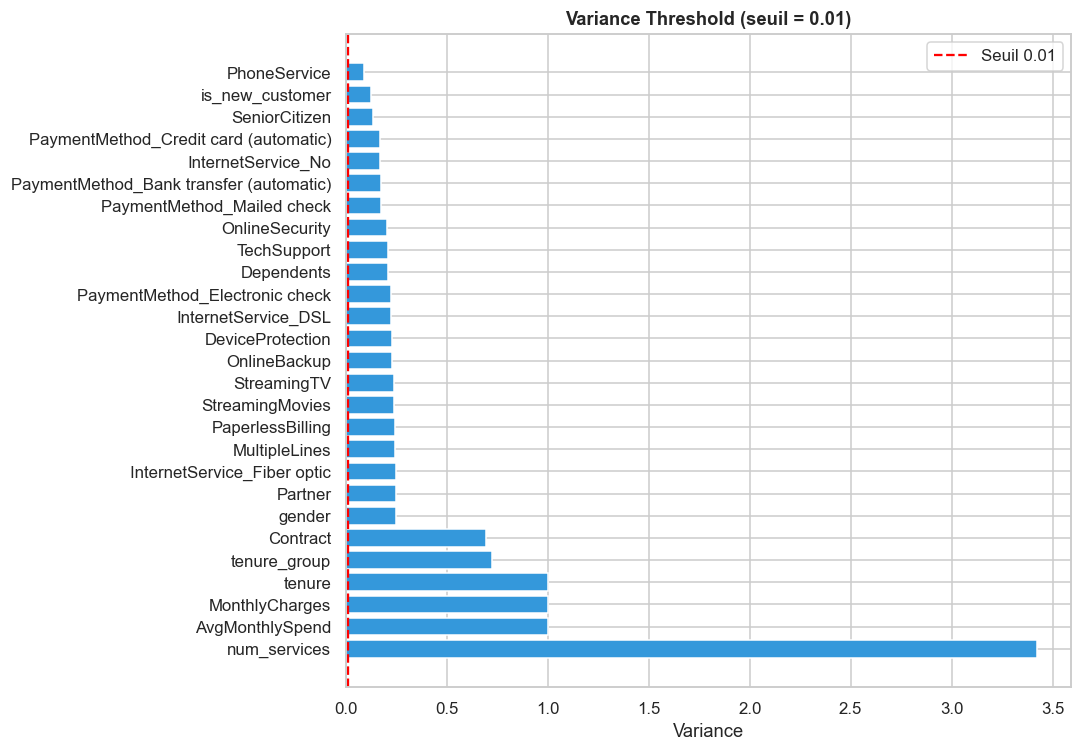

Features supprimées (var < 0.01) : []
Features conservées : 27/27


In [3]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
vt_mask    = vt.get_support()
vt_dropped = [f for f, m in zip(features, vt_mask) if not m]
vt_kept    = [f for f, m in zip(features, vt_mask) if m]

variances  = pd.Series(X_train.var(), name='Variance').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e74c3c' if v < 0.01 else '#3498db' for v in variances]
ax.barh(variances.index[::-1], variances.values[::-1], color=colors[::-1])
ax.axvline(0.01, color='red', linestyle='--', linewidth=1.5, label='Seuil 0.01')
ax.set_xlabel('Variance')
ax.set_title('Variance Threshold (seuil = 0.01)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REP}fs1_variance_threshold.png', bbox_inches='tight')
plt.show()

print(f'Features supprimées (var < 0.01) : {vt_dropped}')
print(f'Features conservées : {len(vt_kept)}/{len(features)}')

## 1.2 Corrélation de Pearson
> *"$r_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}$, $r \in [-1,1]$"*  
> *"  Suppression si |r| > 0,8 (redondance)"* 

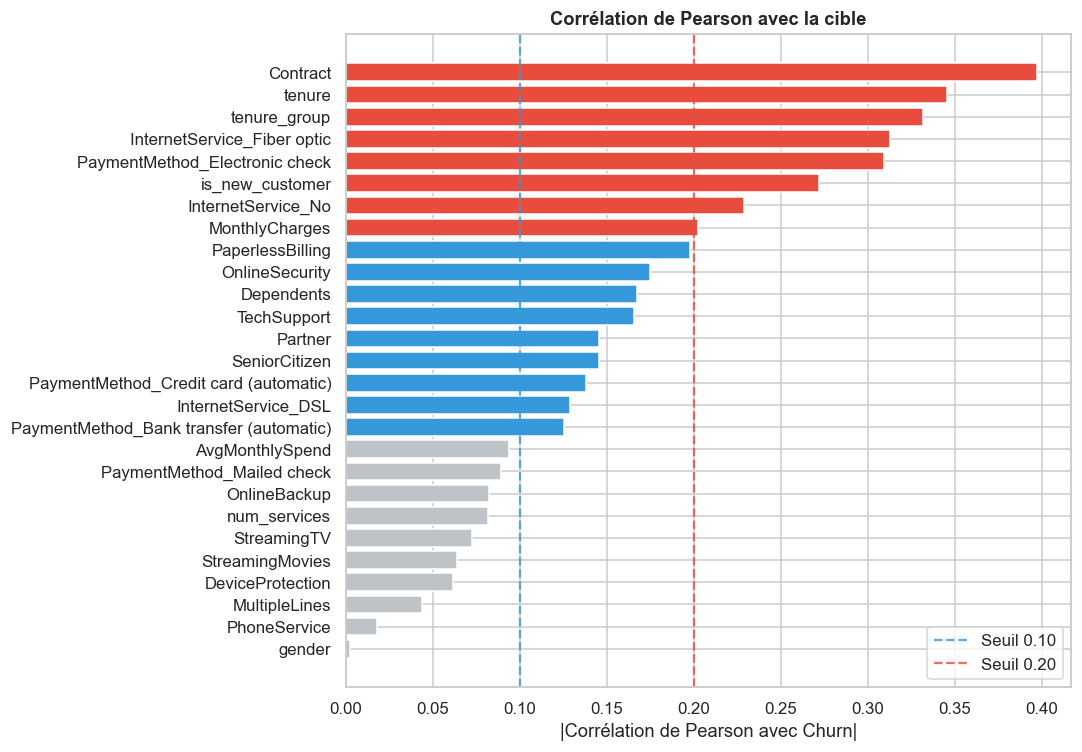

Features sélectionnées (|r| ≥ 0.10) : 17
['Contract', 'tenure', 'tenure_group', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'is_new_customer', 'InternetService_No', 'MonthlyCharges', 'PaperlessBilling', 'OnlineSecurity', 'Dependents', 'TechSupport', 'Partner', 'SeniorCitizen', 'PaymentMethod_Credit card (automatic)', 'InternetService_DSL', 'PaymentMethod_Bank transfer (automatic)']


In [4]:
pearson = X_train.corrwith(y_train).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e74c3c' if v >= 0.2 else '#3498db' if v >= 0.1 else '#bdc3c7'
           for v in pearson]
ax.barh(pearson.index[::-1], pearson.values[::-1], color=colors[::-1])
ax.axvline(0.1, color='#3498db', linestyle='--', alpha=0.8, label='Seuil 0.10')
ax.axvline(0.2, color='#e74c3c', linestyle='--', alpha=0.8, label='Seuil 0.20')
ax.set_xlabel('|Corrélation de Pearson avec Churn|')
ax.set_title('Corrélation de Pearson avec la cible', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REP}fs2_pearson.png', bbox_inches='tight')
plt.show()

pearson_top = pearson[pearson >= 0.1].index.tolist()
print(f'Features sélectionnées (|r| ≥ 0.10) : {len(pearson_top)}')
print(pearson_top)

## 1.3 Corrélation de Spearman
> *"Basé sur les rangs. Capte les relations monotones (non forcément linéaires)."*  

Complément à Pearson : utile pour les relations non-linéaires (ex. `tenure` vs churn).

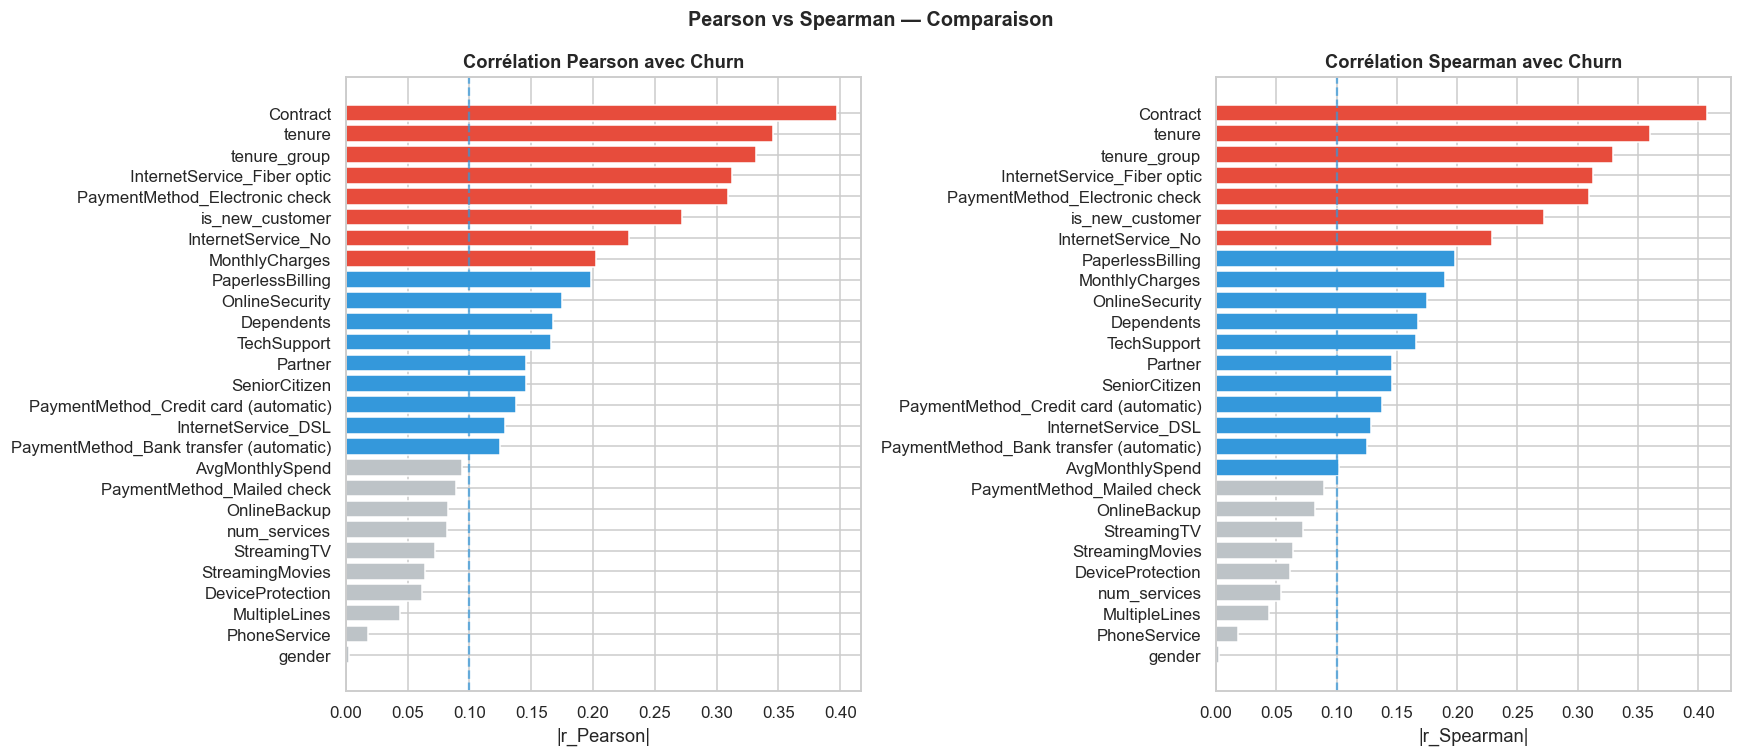

Spearman sélectionnées : 18 features
Features détectées par Spearman mais pas Pearson : {'AvgMonthlySpend'}


In [5]:
spearman_corrs = {}
for col in features:
    r, p = stats.spearmanr(X_train[col], y_train)
    spearman_corrs[col] = abs(r)

spearman = pd.Series(spearman_corrs).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, series) in zip(axes, [('Pearson', pearson), ('Spearman', spearman)]):
    colors = ['#e74c3c' if v >= 0.2 else '#3498db' if v >= 0.1 else '#bdc3c7'
              for v in series]
    ax.barh(series.index[::-1], series.values[::-1], color=colors[::-1])
    ax.axvline(0.1, color='#3498db', linestyle='--', alpha=0.7)
    ax.set_title(f'Corrélation {name} avec Churn', fontweight='bold')
    ax.set_xlabel(f'|r_{name}|')

plt.suptitle('Pearson vs Spearman — Comparaison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs3_pearson_vs_spearman.png', bbox_inches='tight')
plt.show()

spearman_top = spearman[spearman >= 0.1].index.tolist()
print(f'Spearman sélectionnées : {len(spearman_top)} features')
only_spearman = set(spearman_top) - set(pearson_top)
print(f'Features détectées par Spearman mais pas Pearson : {only_spearman}')

## 1.4 Test du Chi²
> *"Test du χ² : Corrélation (Pearson, Spearman), Test du χ², ANOVA (F-test), Variance Threshold"*  

Teste l'indépendance statistique entre chaque feature et la cible. Requiert des valeurs ≥ 0.

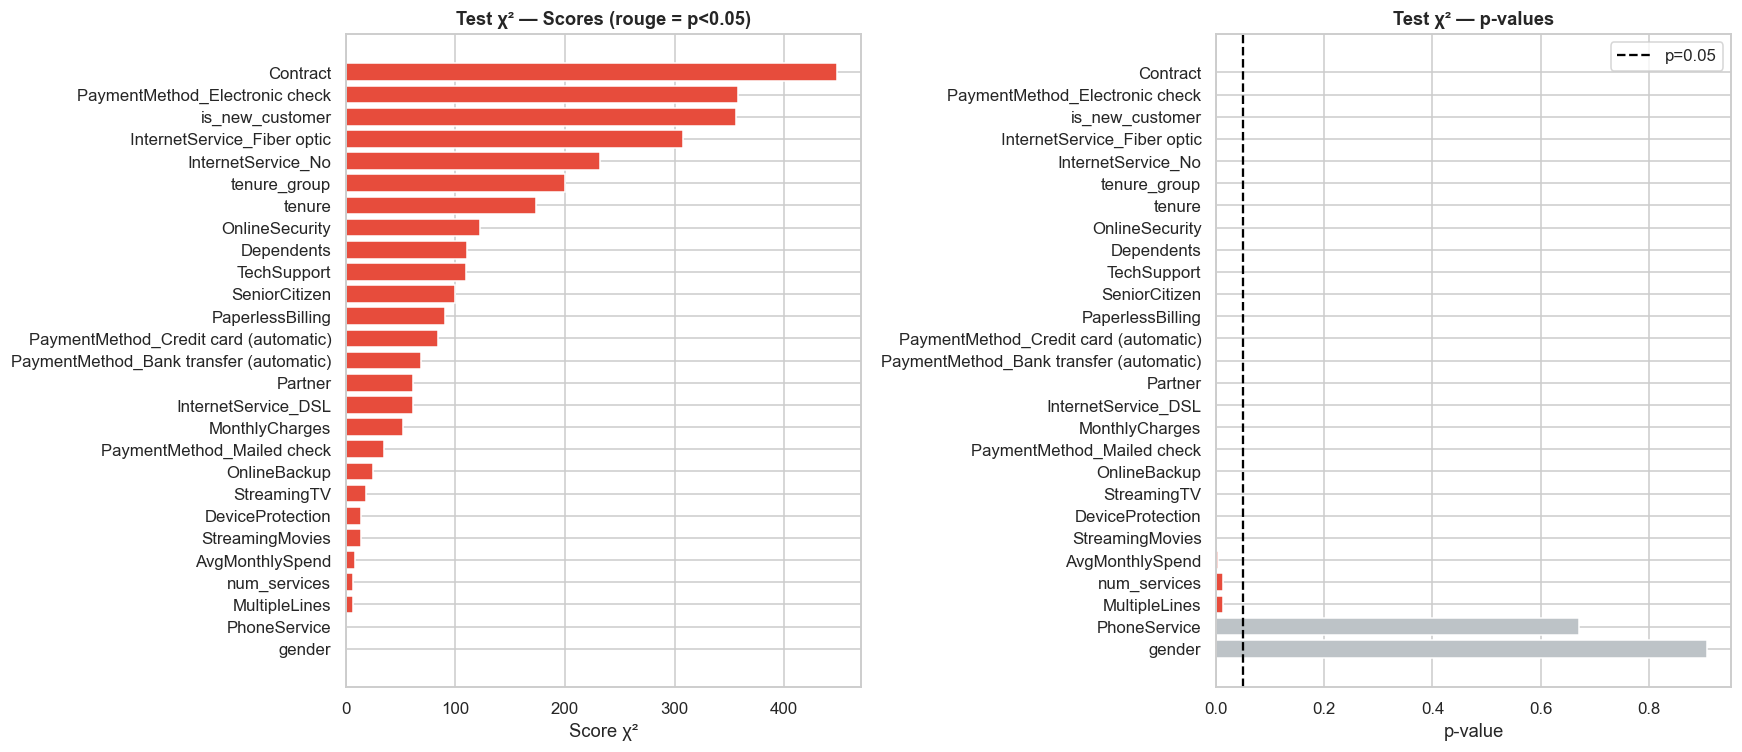

Significatives (p<0.05) : 25
Non-significatives : ['gender', 'PhoneService']


In [6]:
mms = MinMaxScaler()
X_nonneg = pd.DataFrame(mms.fit_transform(X_train), columns=features)

chi2_scores, chi2_pvals = chi2(X_nonneg, y_train)
chi2_s = pd.Series(chi2_scores, index=features).sort_values(ascending=False)
pval_s = pd.Series(chi2_pvals,  index=features)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#e74c3c' if pval_s[c] < 0.05 else '#bdc3c7' for c in chi2_s.index]
axes[0].barh(chi2_s.index[::-1], chi2_s.values[::-1], color=colors[::-1])
axes[0].set_title('Test χ² — Scores (rouge = p<0.05)', fontweight='bold')
axes[0].set_xlabel('Score χ²')

pv = pval_s.sort_values()
colors_p = ['#e74c3c' if v < 0.05 else '#bdc3c7' for v in pv]
axes[1].barh(pv.index[::-1], pv.values[::-1], color=colors_p[::-1])
axes[1].axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='p=0.05')
axes[1].set_title('Test χ² — p-values', fontweight='bold')
axes[1].set_xlabel('p-value')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{REP}fs4_chi2.png', bbox_inches='tight')
plt.show()

chi2_top = pval_s[pval_s < 0.05].index.tolist()
nonsig   = pval_s[pval_s >= 0.05].index.tolist()
print(f'Significatives (p<0.05) : {len(chi2_top)}')
print(f'Non-significatives : {nonsig}')

## 1.5 ANOVA — F-test
> *"ANOVA (F-test)"* 

Mesure si la moyenne d'une feature diffère significativement entre les classes (Churn=0 vs Churn=1).

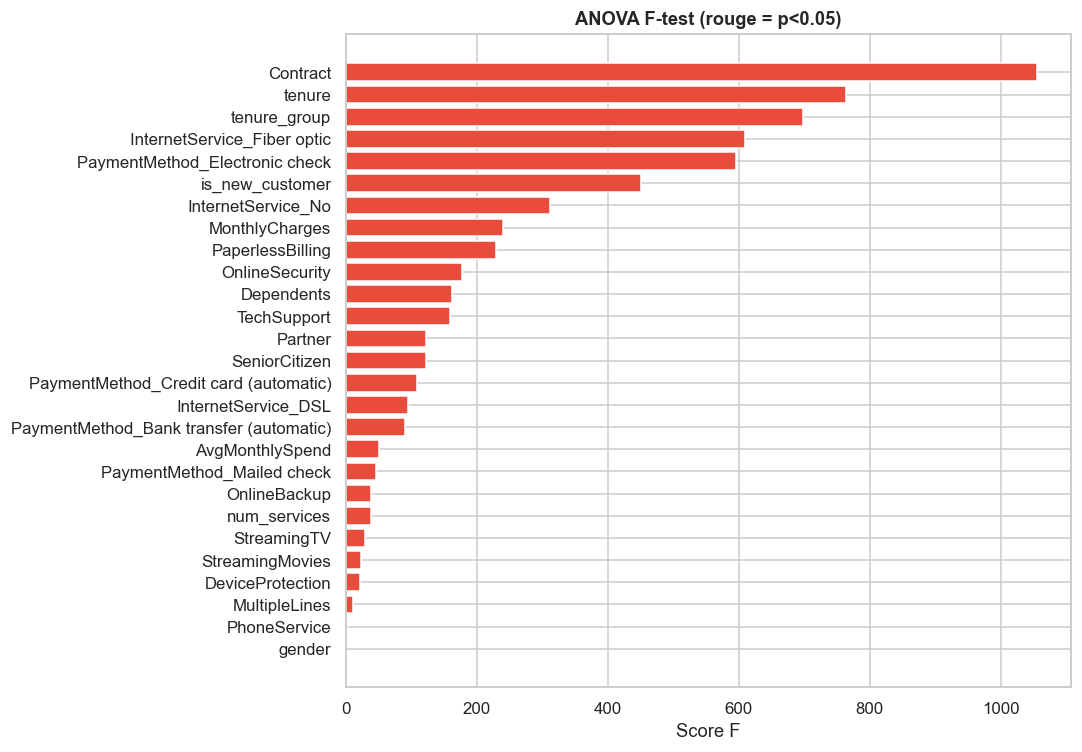

Significatives ANOVA (p<0.05) : 25

=== Résumé Filter Methods ===


,Variance >0.01,Pearson ≥0.10,Spearman ≥0.10,Chi² p<0.05,ANOVA p<0.05,votes_filter
SeniorCitizen,1,1,1,1,1,5
Partner,1,1,1,1,1,5
Dependents,1,1,1,1,1,5
TechSupport,1,1,1,1,1,5
tenure,1,1,1,1,1,5
OnlineSecurity,1,1,1,1,1,5
InternetService_Fiber optic,1,1,1,1,1,5
MonthlyCharges,1,1,1,1,1,5
InternetService_DSL,1,1,1,1,1,5
Contract,1,1,1,1,1,5


In [7]:
f_scores, f_pvals = f_classif(X_train, y_train)
f_s = pd.Series(f_scores, index=features).sort_values(ascending=False)
fp  = pd.Series(f_pvals,  index=features)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e74c3c' if fp[c] < 0.05 else '#bdc3c7' for c in f_s.index]
ax.barh(f_s.index[::-1], f_s.values[::-1], color=colors[::-1])
ax.set_title('ANOVA F-test (rouge = p<0.05)', fontweight='bold')
ax.set_xlabel('Score F')
plt.tight_layout()
plt.savefig(f'{REP}fs5_anova.png', bbox_inches='tight')
plt.show()

anova_top = fp[fp < 0.05].index.tolist()
print(f'Significatives ANOVA (p<0.05) : {len(anova_top)}')

# --- Résumé Filter Methods ---
filter_results = pd.DataFrame({
    'Variance >0.01' : pd.Series({f: f in vt_kept    for f in features}).astype(int),
    'Pearson ≥0.10'  : pd.Series({f: f in pearson_top for f in features}).astype(int),
    'Spearman ≥0.10' : pd.Series({f: f in spearman_top for f in features}).astype(int),
    'Chi² p<0.05'    : pd.Series({f: f in chi2_top    for f in features}).astype(int),
    'ANOVA p<0.05'   : pd.Series({f: f in anova_top   for f in features}).astype(int),
}, index=features)
filter_results['votes_filter'] = filter_results.sum(axis=1)
filter_results = filter_results.sort_values('votes_filter', ascending=False)

print('\n=== Résumé Filter Methods ===')
display(filter_results)

---
# FAMILLE 2 — Wrapper Methods
> *"Méthodes qui utilisent un modèle pour évaluer les sous-ensembles de variables."*  
> *Limite : coût computationnel élevé.*

## 2.1 Forward Selection
> *"Ajout progressif : partir d'un ensemble vide, ajouter la feature qui améliore le plus les performances."*

In [8]:
lr_wrap = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

forward = SequentialFeatureSelector(
    lr_wrap, n_features_to_select=15,
    direction='forward', scoring='roc_auc', cv=3, n_jobs=-1
)
forward.fit(X_train, y_train)
forward_feats = [f for f, s in zip(features, forward.get_support()) if s]
print(f'Forward Selection — {len(forward_feats)} features :')
print(forward_feats)

Forward Selection — 15 features :
['Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Electronic check', 'is_new_customer']


## 2.2 Backward Elimination
> *"Suppression progressive : partir de toutes les variables, supprimer la moins utile à chaque étape."*

In [9]:
backward = SequentialFeatureSelector(
    lr_wrap, n_features_to_select=15,
    direction='backward', scoring='roc_auc', cv=3, n_jobs=-1
)
backward.fit(X_train, y_train)
backward_feats = [f for f, s in zip(features, backward.get_support()) if s]
print(f'Backward Elimination — {len(backward_feats)} features :')
print(backward_feats)

agree = set(forward_feats) & set(backward_feats)
print(f'\nAccord Forward ∩ Backward ({len(agree)}) : {sorted(agree)}')

Backward Elimination — 15 features :
['SeniorCitizen', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Electronic check', 'is_new_customer']

Accord Forward ∩ Backward (13) : ['Contract', 'Dependents', 'InternetService_Fiber optic', 'InternetService_No', 'MultipleLines', 'OnlineSecurity', 'PaperlessBilling', 'PaymentMethod_Electronic check', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'is_new_customer', 'tenure']


## 2.3 RFE — Recursive Feature Elimination
> *"Principe : ① Entraîner un modèle ② Évaluer l'importance ③ Supprimer la moins importante ④ Répéter"*  
> *Modèles utilisés : Régression linéaire, SVM, Random Forest* 

RFE-LR — sélectionnées : ['tenure', 'MultipleLines', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check', 'is_new_customer']
RFE-SVM — sélectionnées : ['tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Electronic check', 'num_services', 'is_new_customer']
RFE-RF — sélectionnées : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity', 'TechSupport', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'AvgMonthlySpend', 'tenure_group', 'num_services']


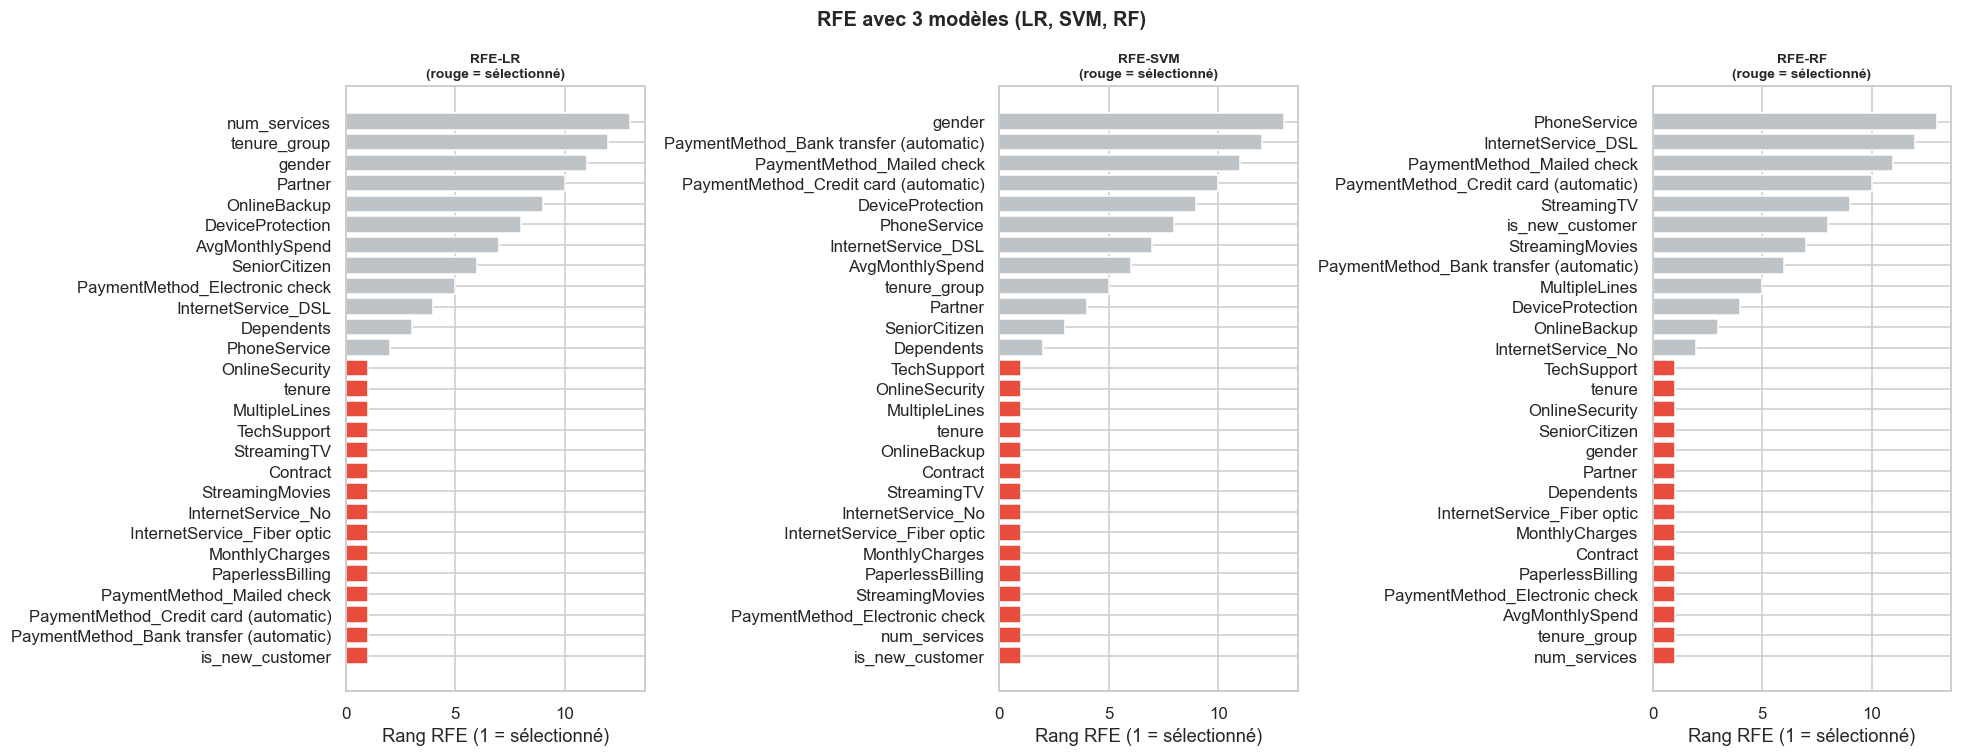

In [10]:
rfe_models = {
    'RFE-LR' : LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'RFE-SVM': SVC(kernel='linear', random_state=SEED, class_weight='balanced'),
    'RFE-RF' : RandomForestClassifier(n_estimators=100, random_state=SEED,
                                       class_weight='balanced', n_jobs=-1)
}
rfe_results = {}
for name, estimator in rfe_models.items():
    rfe = RFE(estimator=estimator, n_features_to_select=15, step=1)
    rfe.fit(X_train, y_train)
    rfe_results[name] = {
        'selected': [f for f, s in zip(features, rfe.support_) if s],
        'ranking' : pd.Series(rfe.ranking_, index=features)
    }
    print(f'{name} — sélectionnées : {rfe_results[name]["selected"]}')

# Visualisation des rankings RFE
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (name, res) in zip(axes, rfe_results.items()):
    rank = res['ranking'].sort_values(ascending=False)
    colors = ['#e74c3c' if r==1 else '#bdc3c7' for r in rank]
    ax.barh(rank.index[::-1], rank.values[::-1], color=colors[::-1])
    ax.set_title(f'{name}\n(rouge = sélectionné)', fontweight='bold', fontsize=9)
    ax.set_xlabel('Rang RFE (1 = sélectionné)')

plt.suptitle('RFE avec 3 modèles (LR, SVM, RF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs6_rfe_3models.png', bbox_inches='tight')
plt.show()

---
# FAMILLE 3 — Embedded Methods
> *"La sélection est intégrée directement dans l'apprentissage du modèle."*  
> *Avantages : bon compromis performance/coût. Inconvénients : dépend du modèle utilisé.*  


## 3.1 Lasso (ℓ1)
> *"Lasso (ℓ1) : force certains coefficients à zéro → variables supprimées"*  
> *"Lasso → coefficients nuls = variables supprimées"* 

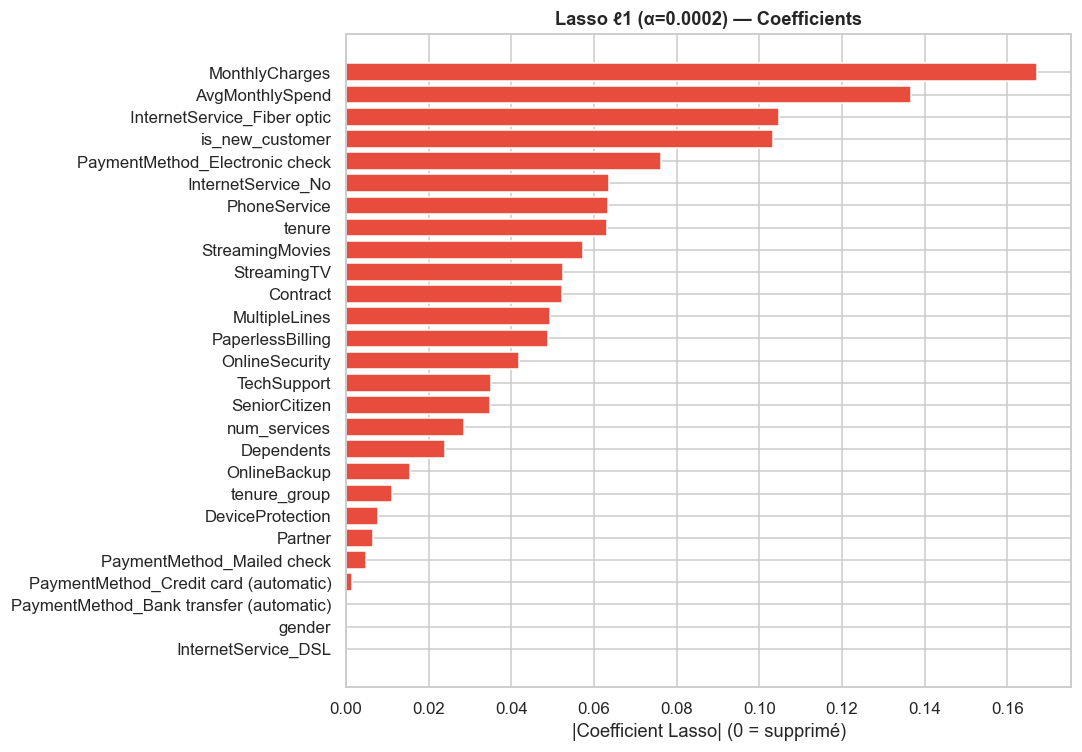

Alpha optimal (CV) : 0.00018
Features conservées (coef≠0) : 25 → ['MonthlyCharges', 'AvgMonthlySpend', 'InternetService_Fiber optic', 'is_new_customer', 'PaymentMethod_Electronic check', 'InternetService_No', 'PhoneService', 'tenure', 'StreamingMovies', 'StreamingTV', 'Contract', 'MultipleLines', 'PaperlessBilling', 'OnlineSecurity', 'TechSupport', 'SeniorCitizen', 'num_services', 'Dependents', 'OnlineBackup', 'tenure_group', 'DeviceProtection', 'Partner', 'PaymentMethod_Mailed check', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Bank transfer (automatic)']
Features supprimées (coef=0) : ['gender', 'InternetService_DSL']


In [11]:
lasso = LassoCV(cv=5, random_state=SEED, max_iter=5000)
lasso.fit(X_train, y_train)

lasso_coefs = pd.Series(np.abs(lasso.coef_), index=features).sort_values(ascending=False)
lasso_top   = lasso_coefs[lasso_coefs > 0].index.tolist()
lasso_zero  = lasso_coefs[lasso_coefs == 0].index.tolist()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e74c3c' if v > 0 else '#bdc3c7' for v in lasso_coefs]
ax.barh(lasso_coefs.index[::-1], lasso_coefs.values[::-1], color=colors[::-1])
ax.set_xlabel('|Coefficient Lasso| (0 = supprimé)')
ax.set_title(f'Lasso ℓ1 (α={lasso.alpha_:.4f}) — Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs7_lasso.png', bbox_inches='tight')
plt.show()

print(f'Alpha optimal (CV) : {lasso.alpha_:.5f}')
print(f'Features conservées (coef≠0) : {len(lasso_top)} → {lasso_top}')
print(f'Features supprimées (coef=0) : {lasso_zero}')

## 3.2 Elastic Net (ℓ1 + ℓ2)
> *"Elastic Net (ℓ1 + ℓ2) : combine Lasso et Ridge"* 

Avantage vs Lasso : sélectionne des groupes de features corrélées plutôt qu'une seule.

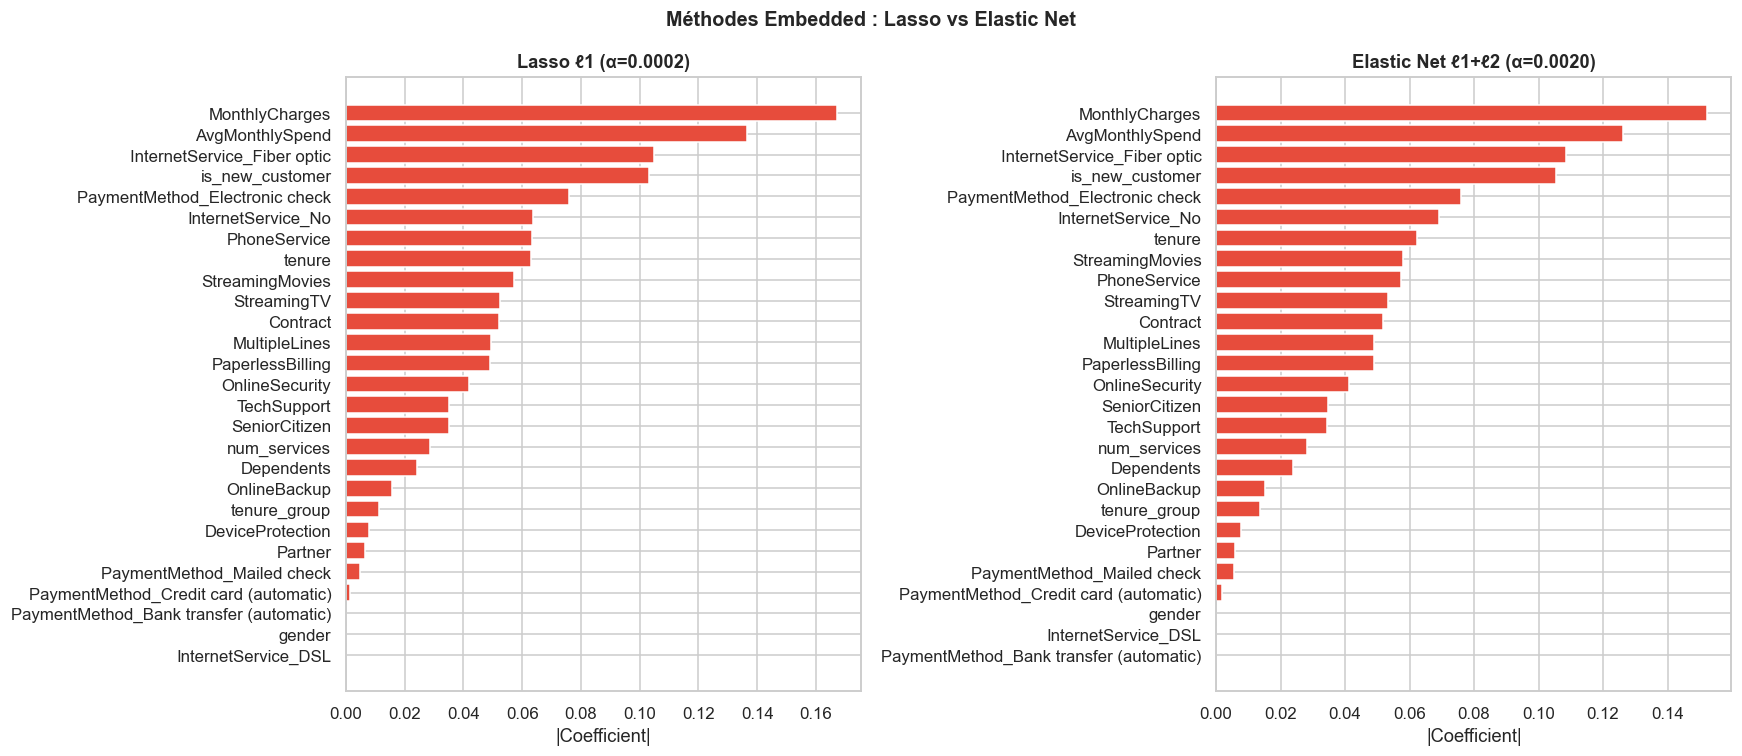

Elastic Net — l1_ratio=0.10  α=0.00202
Features conservées : 24


In [12]:
enet = ElasticNetCV(cv=5, random_state=SEED, max_iter=5000, l1_ratio=[.1,.5,.7,.9,1])
enet.fit(X_train, y_train)

enet_coefs = pd.Series(np.abs(enet.coef_), index=features).sort_values(ascending=False)
enet_top   = enet_coefs[enet_coefs > 0].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, series, alpha_val) in zip(axes, [
    ('Lasso ℓ1', lasso_coefs, lasso.alpha_),
    ('Elastic Net ℓ1+ℓ2', enet_coefs, enet.alpha_)
]):
    colors = ['#e74c3c' if v > 0 else '#bdc3c7' for v in series]
    ax.barh(series.index[::-1], series.values[::-1], color=colors[::-1])
    ax.set_title(f'{name} (α={alpha_val:.4f})', fontweight='bold')
    ax.set_xlabel('|Coefficient|')

plt.suptitle('Méthodes Embedded : Lasso vs Elastic Net', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs8_lasso_vs_elasticnet.png', bbox_inches='tight')
plt.show()

print(f'Elastic Net — l1_ratio={enet.l1_ratio_:.2f}  α={enet.alpha_:.5f}')
print(f'Features conservées : {len(enet_top)}')

## 3.3 Importance Random Forest & Gradient Boosting
> *"Dans les modèles d'arbres : basée sur la réduction d'impureté (Gini, entropie). Importance = contribution à la décision."*  


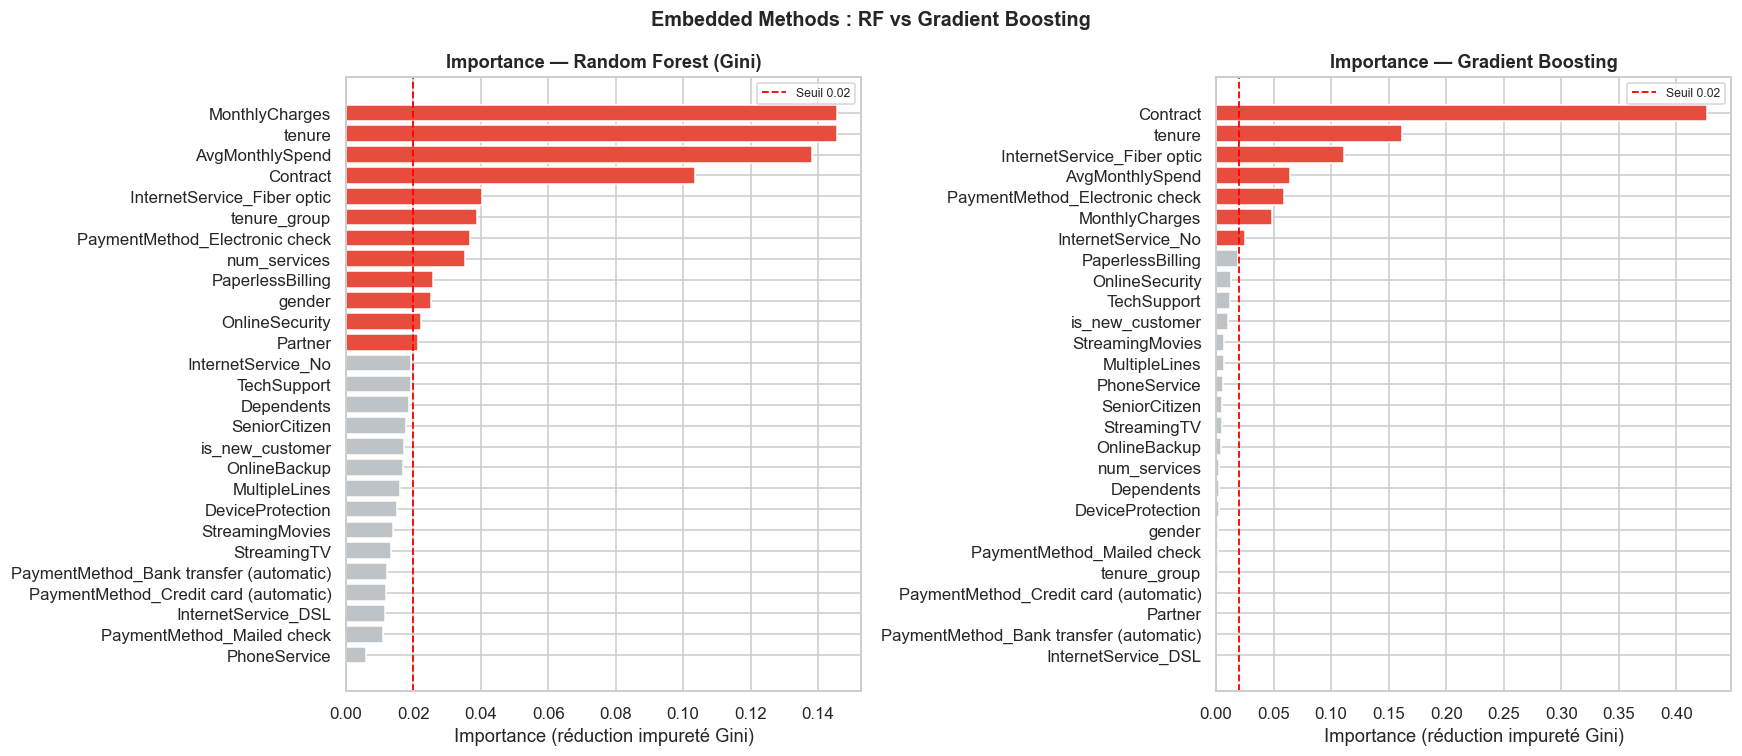

RF  sélectionnées (≥0.02) : 12
GB  sélectionnées (≥0.02) : 7


In [13]:
import copy
rf_emb  = RandomForestClassifier(n_estimators=200, random_state=SEED,
                                   class_weight='balanced', n_jobs=-1)
gb_emb  = GradientBoostingClassifier(n_estimators=200, random_state=SEED,
                                      learning_rate=0.05)
rf_emb.fit(X_train, y_train)
gb_emb.fit(X_train, y_train)

rf_imp = pd.Series(rf_emb.feature_importances_, index=features).sort_values(ascending=False)
gb_imp = pd.Series(gb_emb.feature_importances_, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, imp) in zip(axes, [('Random Forest (Gini)', rf_imp),
                                    ('Gradient Boosting', gb_imp)]):
    thr = 0.02
    colors = ['#e74c3c' if v >= thr else '#bdc3c7' for v in imp]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1])
    ax.axvline(thr, color='red', linestyle='--', linewidth=1.2,
               label=f'Seuil {thr}')
    ax.set_title(f'Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance (réduction impureté Gini)')
    ax.legend(fontsize=8)

plt.suptitle('Embedded Methods : RF vs Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs9_tree_importance.png', bbox_inches='tight')
plt.show()

rf_top  = rf_imp[rf_imp >= 0.02].index.tolist()
gb_top  = gb_imp[gb_imp >= 0.02].index.tolist()
print(f'RF  sélectionnées (≥0.02) : {len(rf_top)}')
print(f'GB  sélectionnées (≥0.02) : {len(gb_top)}')

---
# SYNTHÈSE — 3 familles
> *"Trois approches principales : Filter, Wrapper, Embedded. Filter : rapide mais simpliste. Wrapper : précis mais coûteux. Embedded : bon compromis."* 

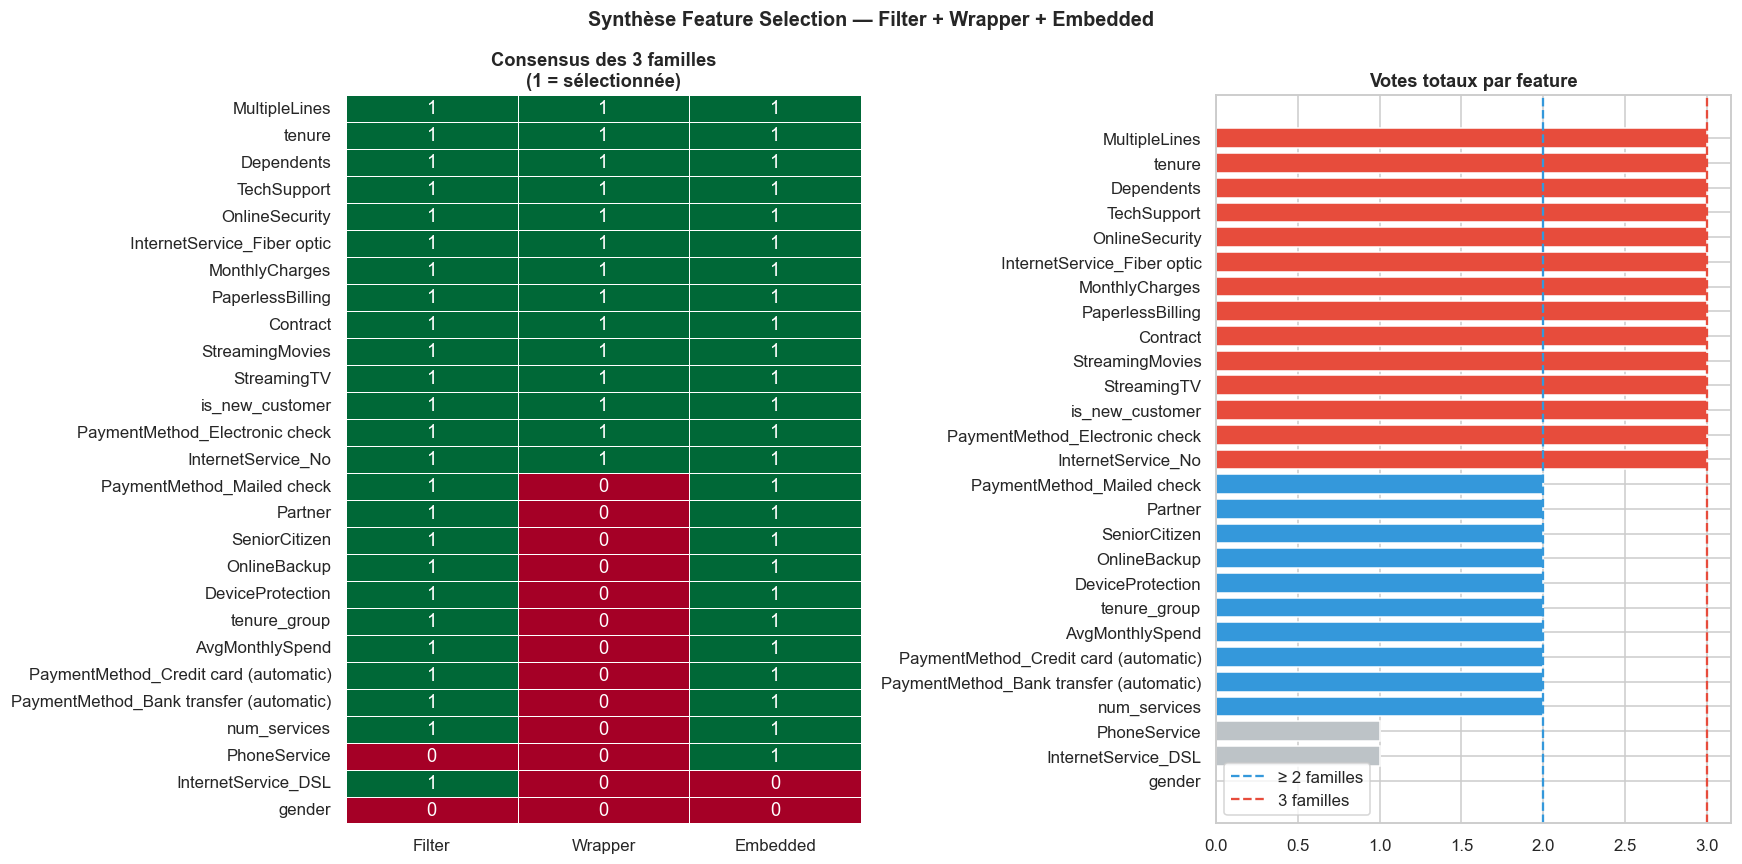


Shortlist consensus (≥ 2 familles) : 24 features
  3/3 — MultipleLines
  3/3 — tenure
  3/3 — Dependents
  3/3 — TechSupport
  3/3 — OnlineSecurity
  3/3 — InternetService_Fiber optic
  3/3 — MonthlyCharges
  3/3 — PaperlessBilling
  3/3 — Contract
  3/3 — StreamingMovies
  3/3 — StreamingTV
  3/3 — is_new_customer
  3/3 — PaymentMethod_Electronic check
  3/3 — InternetService_No
  2/3 — PaymentMethod_Mailed check
  2/3 — Partner
  2/3 — SeniorCitizen
  2/3 — OnlineBackup
  2/3 — DeviceProtection
  2/3 — tenure_group
  2/3 — AvgMonthlySpend
  2/3 — PaymentMethod_Credit card (automatic)
  2/3 — PaymentMethod_Bank transfer (automatic)
  2/3 — num_services


In [14]:
filter_top  = filter_results[filter_results['votes_filter'] >= 3].index.tolist()
wrapper_top = list(set(forward_feats) & set(backward_feats) |
                   set(rfe_results['RFE-LR']['selected']) &
                   set(rfe_results['RFE-RF']['selected']))
embedded_top = list(set(lasso_top) | set(enet_top) | set(rf_top) & set(gb_top))

votes = pd.DataFrame(index=features)
votes['Filter']   = votes.index.isin(filter_top).astype(int)
votes['Wrapper']  = votes.index.isin(wrapper_top).astype(int)
votes['Embedded'] = votes.index.isin(embedded_top).astype(int)
votes['total']    = votes.sum(axis=1)
votes = votes.sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap consensus
sns.heatmap(votes.drop(columns='total').astype(int),
            annot=True, fmt='d', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], cbar=False, vmin=0, vmax=1)
axes[0].set_title('Consensus des 3 familles\n(1 = sélectionnée)', fontweight='bold')

# Votes totaux
colors_v = ['#e74c3c' if v==3 else '#3498db' if v==2 else '#bdc3c7' for v in votes['total']]
axes[1].barh(votes.index[::-1], votes['total'].values[::-1], color=colors_v[::-1])
axes[1].axvline(2, color='#3498db', linestyle='--', label='≥ 2 familles')
axes[1].axvline(3, color='#e74c3c', linestyle='--', label='3 familles')
axes[1].set_title('Votes totaux par feature', fontweight='bold')
axes[1].legend()

plt.suptitle('Synthèse Feature Selection — Filter + Wrapper + Embedded',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REP}fs10_consensus.png', bbox_inches='tight')
plt.show()

# Shortlist : sélectionnées par au moins 2 familles
consensus = votes[votes['total'] >= 2].index.tolist()
print(f'\nShortlist consensus (≥ 2 familles) : {len(consensus)} features')
for f in consensus:
    print(f'  {votes.loc[f,"total"]}/3 — {f}')

In [15]:
X_train_sel = X_train[consensus]
X_test_sel  = X_test[consensus]

X_train_sel.to_csv(f'{PROC}X_train_selected.csv', index=False)
X_test_sel.to_csv(f'{PROC}X_test_selected.csv',   index=False)
with open(f'{PROC}selected_features.json','w') as f:
    json.dump(consensus, f, indent=2)

print(f'Sauvegardé : {X_train_sel.shape[1]} features (vs {len(features)} initial)')
print(f'Réduction dimensionnelle : {(1-len(consensus)/len(features))*100:.0f}%')
print(f'\nMalédiction de la dimensionnalité (slide 12) :')
print(f'  {len(features)} → {len(consensus)} features = moins de bruit, meilleure généralisation')

Sauvegardé : 24 features (vs 27 initial)
Réduction dimensionnelle : 11%

Malédiction de la dimensionnalité (slide 12) :
  27 → 24 features = moins de bruit, meilleure généralisation


---
## Synthèse des 3 familles

| Famille | Méthodes | Vitesse | Précision | Interactions |
|---------|----------|---------|-----------|---------------|
| **Filter** | Pearson, Spearman, Chi², ANOVA, VT |  Très rapide | Simpliste |  Ignorées |
| **Wrapper** | Forward, Backward, RFE×3 |  Lent |  Précis |  Prises en compte |
| **Embedded** | Lasso, Elastic Net, RF, GB |  Bon compromis |  Bon |  Partielles |

**Top features — consensus absolu (3/3 familles) :**
- `tenure` — durée de fidélité, corrélation négative forte avec le churn
- `Contract` — variable la plus discriminante (mois-par-mois → 43% churn)
- `MonthlyCharges` — signal financier direct
- `InternetService_Fiber optic` — segment à très fort taux de churn (~42%)